In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df = pd.read_csv('controls.csv', index_col=0)

In [3]:
#Garbage filters

df = df[df['circ_cell_original'] < 0.8]
df = df[df['circ_cell_original'] > 0.3]
df = df[df['area_cell_original'] > 2000]
df = df[df['area_cell_original'] < 25000]

df = df[df['area_nuc'] < 5000]
df = df[df['area_nuc'] > 600]

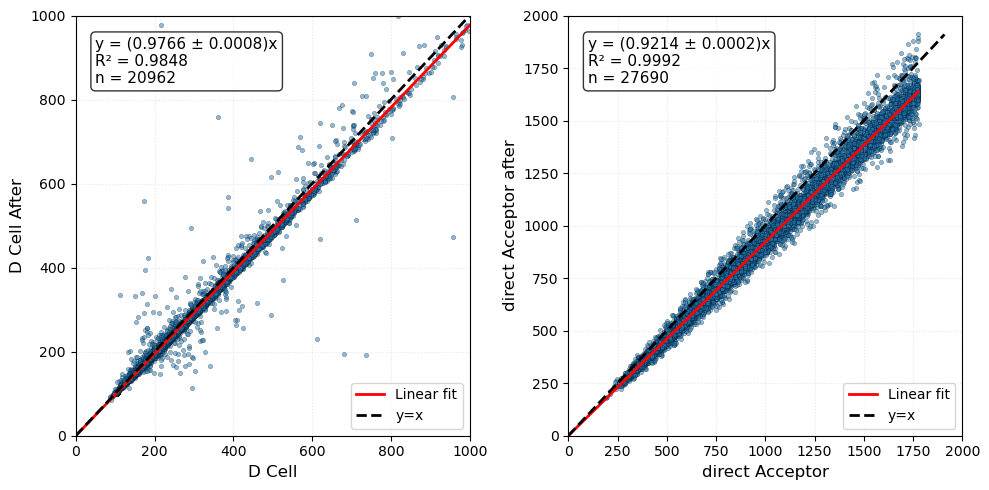

In [4]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# ========== LEFT SUBPLOT: D_cell ==========
# Remove NaN values for regression
data_D = df[['D_cell', 'D_cell_after']].dropna()

x_D = data_D['D_cell'].values
y_D = data_D['D_cell_after'].values

# Define linear function through origin
def linear_through_origin(x, slope):
    return slope * x

# Use curve_fit to get slope and covariance matrix
popt_D, pcov_D = curve_fit(linear_through_origin, x_D, y_D)
slope_D = popt_D[0]
std_err_slope_D = np.sqrt(pcov_D[0, 0])

# Calculate R² for regression through origin
ss_res_D = np.sum((y_D - slope_D * x_D)**2)
ss_tot_D = np.sum(y_D**2)
r_squared_D = 1 - (ss_res_D / ss_tot_D)

# Plot scatter
ax1.scatter(df['D_cell'], df['D_cell_after'], 
           alpha=0.5, s=10, edgecolors='black', linewidth=0.3)

# Add regression line through origin
x_line_D = np.linspace(0, data_D['D_cell'].max(), 100)
y_line_D = slope_D * x_line_D
ax1.plot(x_line_D, y_line_D, color='red', linewidth=2, label='Linear fit')

# Add y=x line
max_val_D = max(data_D['D_cell'].max(), data_D['D_cell_after'].max())
ax1.plot([0, max_val_D], [0, max_val_D], 'k--', linewidth=2, alpha=1, label='y=x')

# Add formula text
formula_text_D = f'y = ({slope_D:.4f} ± {std_err_slope_D:.4f})x\nR² = {r_squared_D:.4f}\nn = {len(data_D)}'
ax1.text(0.05, 0.95, formula_text_D, transform=ax1.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('D Cell', fontsize=12)
ax1.set_ylabel('D Cell After', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.set_xlim(0, 1000)
ax1.set_ylim(0, 1000)
ax1.legend(loc='lower right', fontsize=10)

# ========== RIGHT SUBPLOT: directA_cell on GOOSE constructs ==========
df = pd.read_csv('cells_concat_filtered.csv', index_col=0)
data_A = df[['directA_cell', 'directA_cell_after']].dropna()

x_A = data_A['directA_cell'].values
y_A = data_A['directA_cell_after'].values

# Use curve_fit to get slope and covariance matrix
popt_A, pcov_A = curve_fit(linear_through_origin, x_A, y_A)
slope_A = popt_A[0]
std_err_slope_A = np.sqrt(pcov_A[0, 0])

# Calculate R² for regression through origin
ss_res_A = np.sum((y_A - slope_A * x_A)**2)
ss_tot_A = np.sum(y_A**2)
r_squared_A = 1 - (ss_res_A / ss_tot_A)

# Plot scatter
ax2.scatter(df['directA_cell'], df['directA_cell_after'], 
           alpha=0.5, s=10, edgecolors='black', linewidth=0.3)

# Add regression line through origin
x_line_A = np.linspace(0, data_A['directA_cell'].max(), 100)
y_line_A = slope_A * x_line_A
ax2.plot(x_line_A, y_line_A, color='red', linewidth=2, label='Linear fit')

# Add y=x line
max_val_A = max(data_A['directA_cell'].max(), data_A['directA_cell_after'].max())
ax2.plot([0, max_val_A], [0, max_val_A], 'k--', linewidth=2, alpha=1, label='y=x')

# Add formula text
formula_text_A = f'y = ({slope_A:.4f} ± {std_err_slope_A:.4f})x\nR² = {r_squared_A:.4f}\nn = {len(data_A)}'
ax2.text(0.05, 0.95, formula_text_A, transform=ax2.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('direct Acceptor', fontsize=12)
ax2.set_ylabel('direct Acceptor after', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.set_xlim(0, 2000)
ax2.set_ylim(0, 2000)
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('Figure_graphs/FigSI/PerturbCorrections.svg')